In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
# 2. Load Data

transactions = pd.read_excel(r"C:\Users\prati\OneDrive\Desktop\doctata\QVI_transaction_data.xlsx")
purchase = pd.read_csv(r"C:\Users\prati\OneDrive\Desktop\doctata\QVI_purchase_behaviour .csv")

In [4]:
# 3. View First Rows
transactions.head()
purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
# 4. Check Shape
print("Transactions Shape:", transactions.shape)
print("Purchase Shape:", purchase.shape)

Transactions Shape: (264836, 8)
Purchase Shape: (72637, 3)


In [7]:
# 5. Check Data Types
transactions.info()
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
m

In [8]:
# 6. Missing Values
transactions.isnull().sum()
purchase.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [9]:
# 7. Merge Both Tables
df = pd.merge(transactions, purchase, on="LYLTY_CARD_NBR", how="left")

print("\nMerged Data")
print(df.head())



Merged Data
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  \
0    Natural Chip        Compny SeaSalt175g         2        6.0   
1                  CCs Nacho Cheese    175g         3        6.3   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9   
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0   
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/COUPLES           Budget  
2  MIDAGE SINGLES/COUPLES           Budget  
3  MIDAGE SINGLES/COUPLES           Budget  
4  MIDAGE 

In [10]:
# 8. Convert Date Column
# If DATE is number format
try:
    df["DATE"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["DATE"], unit="D")
except:
    df["DATE"] = pd.to_datetime(df["DATE"])


In [11]:
# 9. Basic Summary
print(df.describe())

                                DATE     STORE_NBR  LYLTY_CARD_NBR  \
count                         264836  264836.00000    2.648360e+05   
mean   2018-12-30 00:52:12.879215616     135.08011    1.355495e+05   
min              2018-07-01 00:00:00       1.00000    1.000000e+03   
25%              2018-09-30 00:00:00      70.00000    7.002100e+04   
50%              2018-12-30 00:00:00     130.00000    1.303575e+05   
75%              2019-03-31 00:00:00     203.00000    2.030942e+05   
max              2019-06-30 00:00:00     272.00000    2.373711e+06   
std                              NaN      76.78418    8.057998e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  
count  2.648360e+05  264836.000000  264836.000000  264836.000000  
mean   1.351583e+05      56.583157       1.907309       7.304200  
min    1.000000e+00       1.000000       1.000000       1.500000  
25%    6.760150e+04      28.000000       2.000000       5.400000  
50%    1.351375e+05      56.000000

In [12]:
# 10. Remove Outliers
# Remove quantity above 10
df = df[df["PROD_QTY"] < 10]

In [13]:
# 11. Create Pack Size Column

df["PACK_SIZE"] = df["PROD_NAME"].str.extract("(\d+)").astype(float)

In [14]:
# 12. Create Brand Column

df["BRAND"] = df["PROD_NAME"].str.split().str[0]

In [15]:
# 13. Check Unique Segments

print(df["LIFESTAGE"].unique())
print(df["PREMIUM_CUSTOMER"].unique())

['YOUNG SINGLES/COUPLES' 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES'
 'OLDER FAMILIES' 'OLDER SINGLES/COUPLES' 'RETIREES' 'YOUNG FAMILIES']
['Premium' 'Budget' 'Mainstream']


In [16]:
# 14. Total Sales

print("Total Sales:", df["TOT_SALES"].sum())

Total Sales: 1933115.0000000002


LIFESTAGE
OLDER SINGLES/COUPLES     402426.75
RETIREES                  366470.90
OLDER FAMILIES            352467.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64


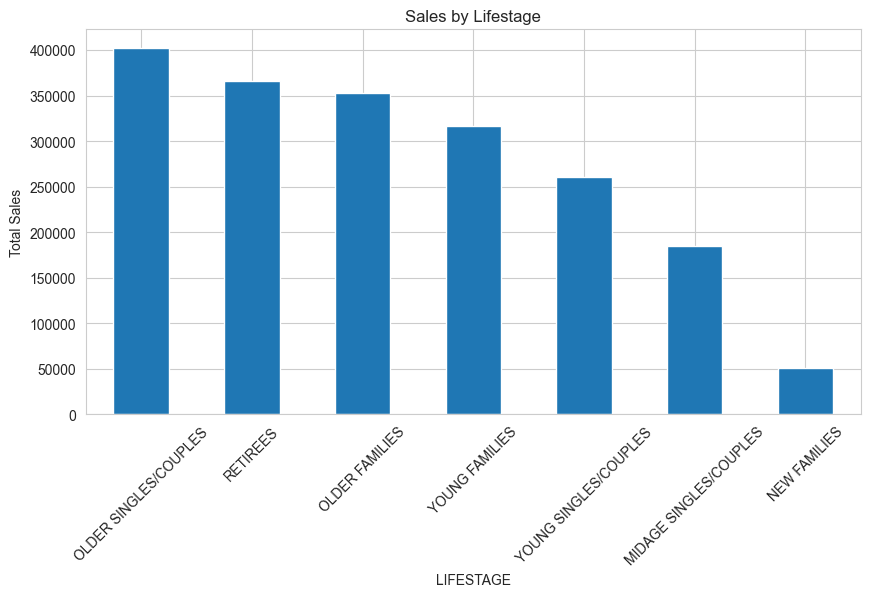

In [17]:
# 15. Sales by Lifestage

life_sales = df.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)
print(life_sales)

plt.figure(figsize=(10,5))
life_sales.plot(kind="bar")
plt.title("Sales by Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


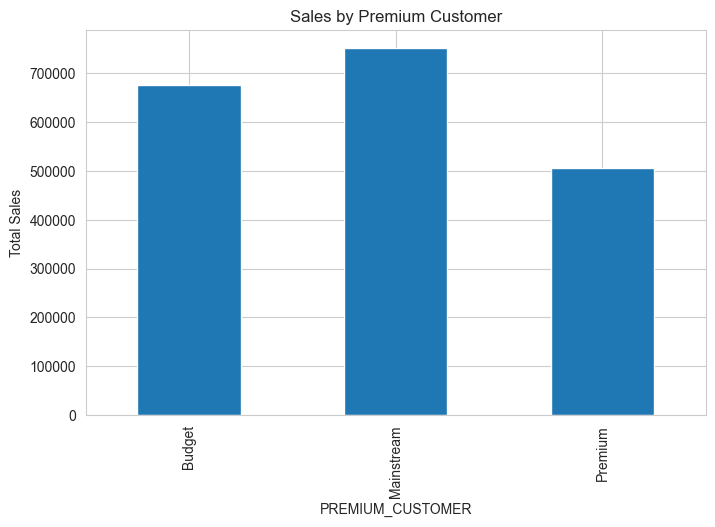

In [ ]:
# 16. Sales by Premium Customer

premium_sales = df.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum()

plt.figure(figsize=(8,5))
premium_sales.plot(kind="bar")
plt.title("Sales by Premium Customer")
plt.ylabel("Total Sales")
plt.show()


In [19]:
# 17. Customer Segment Analysis

segment = df.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
).agg(
    Total_Sales=("TOT_SALES", "sum"),
    Total_Qty=("PROD_QTY", "sum"),
    Customers=("LYLTY_CARD_NBR", "nunique"),
    Avg_Spend=("TOT_SALES", "mean")
).reset_index()

print(segment)

                 LIFESTAGE PREMIUM_CUSTOMER  Total_Sales  Total_Qty  \
0   MIDAGE SINGLES/COUPLES           Budget     35514.80       9496   
1   MIDAGE SINGLES/COUPLES       Mainstream     90803.85      22699   
2   MIDAGE SINGLES/COUPLES          Premium     58432.65      15526   
3             NEW FAMILIES           Budget     21928.45       5571   
4             NEW FAMILIES       Mainstream     17013.90       4319   
5             NEW FAMILIES          Premium     11491.10       2957   
6           OLDER FAMILIES           Budget    168363.25      45065   
7           OLDER FAMILIES       Mainstream    103445.55      27756   
8           OLDER FAMILIES          Premium     80658.40      21771   
9    OLDER SINGLES/COUPLES           Budget    136769.80      35220   
10   OLDER SINGLES/COUPLES       Mainstream    133393.80      34997   
11   OLDER SINGLES/COUPLES          Premium    132263.15      33986   
12                RETIREES           Budget    113147.80      28764   
13    

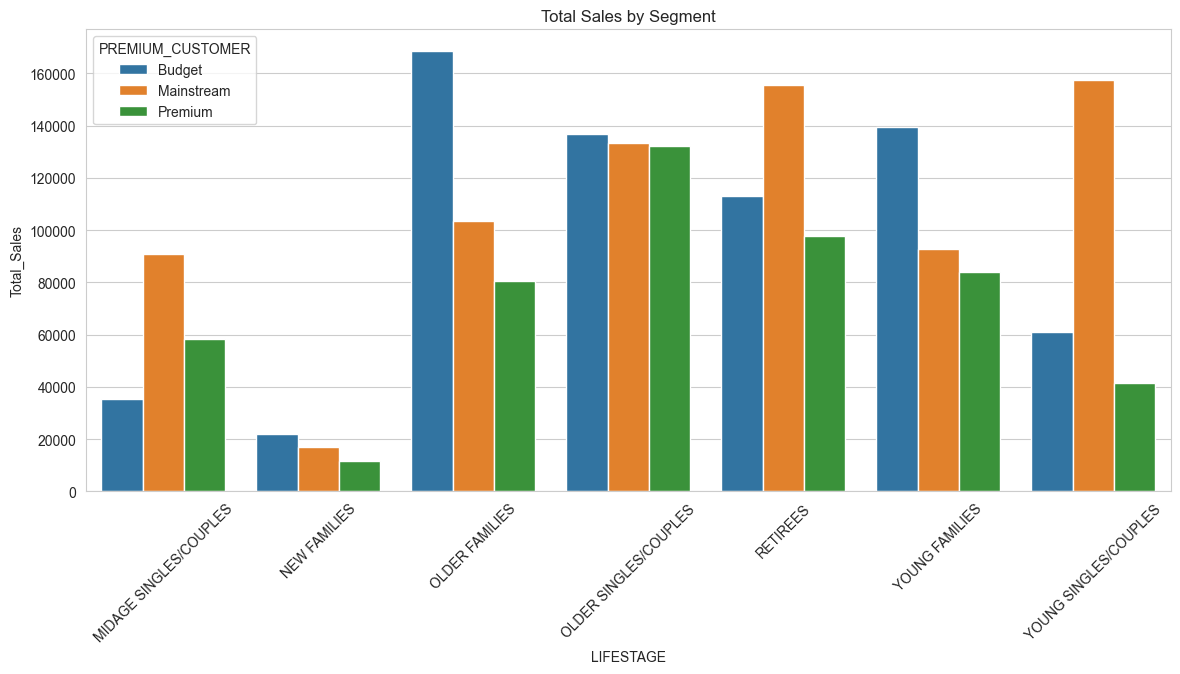

In [20]:
# 18. Segment Sales Chart

plt.figure(figsize=(14,6))
sns.barplot(
    data=segment,
    x="LIFESTAGE",
    y="Total_Sales",
    hue="PREMIUM_CUSTOMER"
)
plt.title("Total Sales by Segment")
plt.xticks(rotation=45)
plt.show()


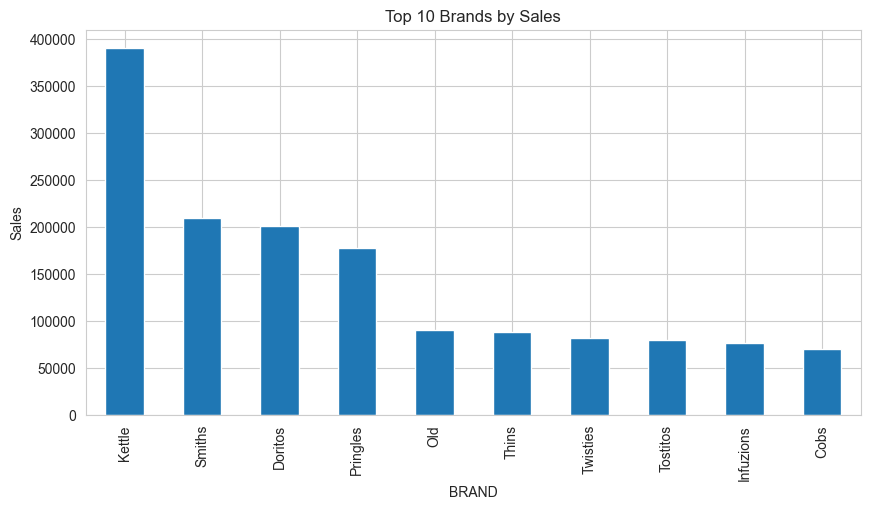

BRAND
Kettle       390239.8
Smiths       210076.8
Doritos      201538.9
Pringles     177655.5
Old           90785.1
Thins         88852.5
Twisties      81522.1
Tostitos      79789.6
Infuzions     76247.6
Cobs          70569.8
Name: TOT_SALES, dtype: float64


In [21]:
# 19. Top 10 Brands

top_brand = df.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_brand.plot(kind="bar")
plt.title("Top 10 Brands by Sales")
plt.ylabel("Sales")
plt.show()

print(top_brand)

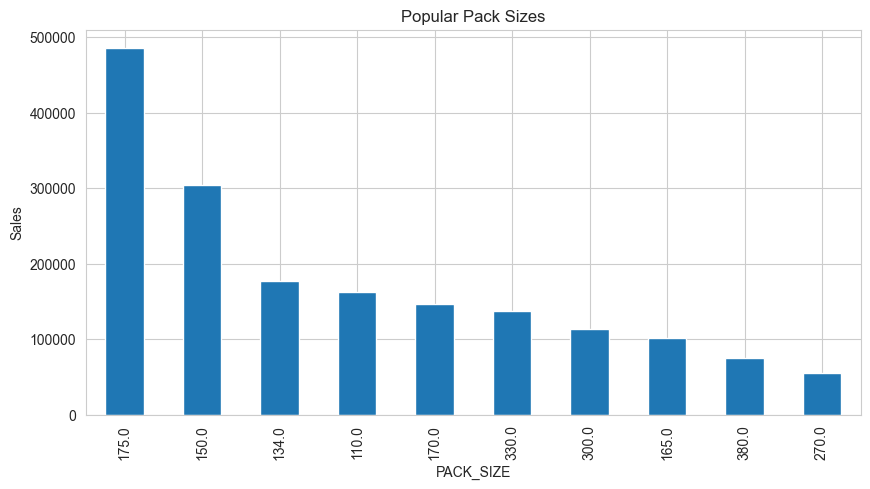

In [22]:
# 20. Most Popular Pack Sizes

pack = df.groupby("PACK_SIZE")["TOT_SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
pack.plot(kind="bar")
plt.title("Popular Pack Sizes")
plt.ylabel("Sales")
plt.show()

In [23]:
# 21. Average Price Per Unit

df["PRICE_PER_UNIT"] = df["TOT_SALES"] / df["PROD_QTY"]

print("Average Price Per Unit:", df["PRICE_PER_UNIT"].mean())

Average Price Per Unit: 3.824628748574579


In [24]:
# 22. Key Insights

print("\n==============================")
print("BUSINESS INSIGHTS")
print("==============================")
print("1. Families and mainstream customers generate strong sales.")
print("2. Premium customers spend more per purchase.")
print("3. Large pack sizes are preferred by family segments.")
print("4. Top brands contribute major revenue.")
print("5. Opportunity: Promotions for families and premium bundles.")



BUSINESS INSIGHTS
1. Families and mainstream customers generate strong sales.
2. Premium customers spend more per purchase.
3. Large pack sizes are preferred by family segments.
4. Top brands contribute major revenue.
5. Opportunity: Promotions for families and premium bundles.


In [26]:
#23. Save Final File

df.to_csv("Final_Quantium_Output.csv", index=False)

print("\nAnalysis Completed Successfully")


Analysis Completed Successfully


In [27]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\prati\OneDrive\Desktop\doctata
['.venv', 'analysis.ipynb', 'Final_Quantium_Output.csv', 'QVI_purchase_behaviour .csv', 'QVI_transaction_data.xlsx']
